<a href="https://colab.research.google.com/github/iestleija/5094-Matematicas/blob/Unidad3/Unidad3/Practices/5094_U3_C5_266229.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Maestría en Inteligencia Artificial y Analítica de Datos

- Curso: **Matemáticas y estadística para inteligencia artificial**

- Semestre: Enero-Junio

- Profesor: Dra. Helen Clara Peñate Rodríguez
- Actividad: **C5. Estadística**
- Alumno: Ismael Estrada Leija
- Matrícula: 266229

# Taller: Muestreo e inferencia en un sistema de recomendaciones (CTR/CVR)

**Contexto (nuestro ejemplo):** tenemos tres modelos de recomendación **A, B y C**.  
Cada vez que el sistema muestra una recomendación a un usuario ocurre una **impresión** (evento).  
En cada impresión registramos si hubo **clic** (0/1) y si luego hubo **conversión** (0/1).

**Objetivos del taller**
1. Conectar *población, muestra, individuo, variable y dato* con el caso de recomendaciones.
2. Simular una población de impresiones y construir **muestras** con distintos tipos de muestreo (probabilístico y no probabilístico).
3. Calcular **CTR** (Click-Trough Rate) y **CVR** (Conversion Rate) y comparar modelos.
4. Construir **intervalos de confianza** para CTR.
5. Estimar **tamaño de muestra** necesario para un margen de error dado.
6. Plantear y ejecutar **pruebas de hipótesis** (una cola y dos colas) para comparar CTR.

> **Convención:** trabajaremos principalmente con **impresiones** como *individuos* (unidad de análisis).  
> Entonces, para una impresión: $(X = 1)$ si hubo clic y $(X = 0)$ si no.  
> En este caso, $(CTR = E[X])$ (promedio de una variable binaria).


## 1) Preparación

Usaremos: `numpy`, `pandas` y `matplotlib`.  
**Regla de visualización:** una gráfica por celda.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from math import sqrt
from scipy.stats import norm

np.random.seed(42)

plt.rcParams["figure.figsize"] = (8, 4)
plt.rcParams["axes.grid"] = True

def print_bold(msg):
    print("\n\033[1m" + msg + "\033[0m")


## 2) Simulación de datos (población de impresiones)

Simularemos una población de impresiones con:
- `model`: A, B o C  
- `user_id`: id de usuario  
- `timestamp`: tiempo (para muestreo sistemático)  
- `country`, `device`, `segment`, `region` (para estratos / conglomerados)  
- `click` (0/1) y `conversion` (0/1, condicionado a click)

Ajustaremos tasas para que:
- el $CTR$ de $B$ sea cercano a 12% (como en el ejemplo de clase),
- $C$ sea ligeramente mejor,
- $A$ ligeramente peor.


In [4]:
N = 200_000  # población grande de impresiones (eventos)
models = np.random.choice(["A", "B", "C"], size=N, p=[0.34, 0.33, 0.33])

# metadatos
user_id = np.random.randint(1, 50_001, size=N)  # 50k usuarios
country = np.random.choice(["MX", "US", "CO", "AR"], size=N, p=[0.55, 0.25, 0.12, 0.08])
device = np.random.choice(["mobile", "desktop"], size=N, p=[0.72, 0.28])
segment = np.random.choice(["new", "returning", "low_activity"], size=N, p=[0.40, 0.45, 0.15])
region = np.random.choice(["north", "center", "south", "west", "east"], size=N)

# timestamps (simulamos una semana, en minutos)
minutes_in_week = 7 * 24 * 60
timestamp_minute = np.random.randint(0, minutes_in_week, size=N)

# probabilidades base de clic por modelo (CTR verdadero de la población)
p_click = {"A": 0.10, "B": 0.12, "C": 0.135}

# pequeños efectos por dispositivo/segmento (para que estratificar tenga sentido)
device_factor = {"mobile": 1.00, "desktop": 0.92}
segment_factor = {"new": 0.95, "returning": 1.05, "low_activity": 0.80}

# probabilidad de clic por impresión
p = np.array([p_click[m] for m in models])     * np.array([device_factor[d] for d in device])     * np.array([segment_factor[s] for s in segment])

p = np.clip(p, 0.001, 0.5)

click = (np.random.rand(N) < p).astype(int)

# probabilidad de conversión dado clic (CVR), depende de modelo
p_conv_given_click = {"A": 0.20, "B": 0.25, "C": 0.27}
q = np.array([p_conv_given_click[m] for m in models])
conversion = ((np.random.rand(N) < q) & (click == 1)).astype(int)

df = pd.DataFrame({
    "model": models,
    "user_id": user_id,
    "timestamp_minute": timestamp_minute,
    "country": country,
    "device": device,
    "segment": segment,
    "region": region,
    "click": click,
    "conversion": conversion
})

print_bold('Población simulada')
df



Población simulada


,model,user_id,timestamp_minute,country,device,segment,region,click,conversion
0,B,44872,3668,MX,mobile,returning,center,0,0
1,C,26634,4194,US,mobile,returning,east,0,0
2,C,12235,7221,CO,mobile,returning,east,0,0
3,B,19536,9225,MX,mobile,returning,north,0,0
4,A,9145,4260,MX,mobile,new,center,0,0
...,...,...,...,...,...,...,...,...,...
199995,B,22481,8996,MX,mobile,low_activity,center,0,0
199996,B,18032,1168,MX,desktop,low_activity,south,1,0
199997,A,27156,4315,CO,mobile,new,south,0,0
199998,B,4532,1689,MX,mobile,new,east,0,0


## 3) Conceptos (población, muestra, individuo, variable, dato) en este taller

- **Población:** todas las *impresiones* generadas en el periodo (aquí, todo `df`).
- **Muestra:** subconjunto de impresiones que seleccionamos para estimar métricas.
- **Individuo:** una impresión (una fila del dataset).
- **Variables:** `click` y `conversion` (y metadatos como `country`, `device`, etc.).
- **Dato:** por ejemplo, en la impresión #814, `click=1` y `conversion=0`.

En lo que sigue, construiremos diferentes muestras para ver cómo cambia (o se sesga) la estimación del CTR/CVR.


## 4) Métricas del *universo* (solo para referencia)

En la práctica no conoceríamos los valores verdaderos; aquí los calculamos para comparar con las estimaciones de las muestras.


In [5]:
def metrics_by_model(data: pd.DataFrame) -> pd.DataFrame:
    g = data.groupby("model").agg(
        impressions=("click", "size"),
        clicks=("click", "sum"),
        conversions=("conversion", "sum")
    )
    g["CTR"] = g["clicks"] / g["impressions"]
    g["CVR"] = np.where(g["clicks"] > 0, g["conversions"] / g["clicks"], np.nan)
    return g.sort_index()

true_metrics = metrics_by_model(df)
print_bold('Métricas de la población simulada')
true_metrics



Métricas de la población simulada


,impressions,clicks,conversions,CTR,CVR
model,,,,,
A,67911,6501,1334,0.095728,0.205199
B,66069,7495,1888,0.113442,0.251901
C,66020,8435,2199,0.127764,0.260699


Un histograma rápido de la variable `click` (binaria) y un conteo por modelo.

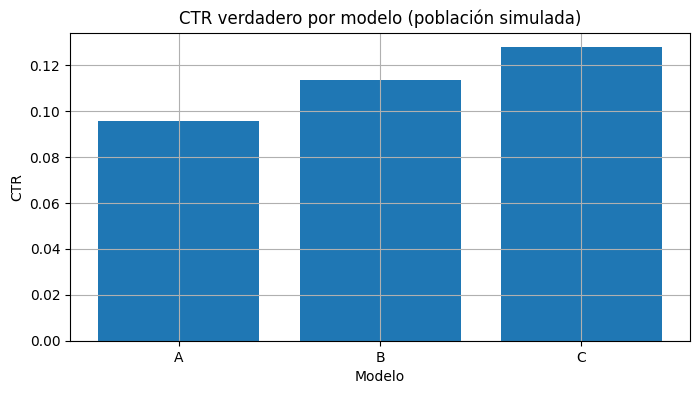

In [6]:
counts = df.groupby("model")["click"].mean().rename("CTR_true").reset_index()

plt.figure()
plt.bar(counts["model"], counts["CTR_true"])
plt.title("CTR verdadero por modelo (población simulada)")
plt.xlabel("Modelo")
plt.ylabel("CTR")
plt.show()


## 5) Muestreo probabilístico (sobre impresiones)

Vamos a construir muestras de tamaño similar (por ejemplo, 3000 impresiones) usando:
- Aleatorio simple
- Sistemático (por tiempo)
- Estratificado (por país)
- Por conglomerados (por región)

Luego estimaremos CTR y CVR con cada muestra.


In [7]:
def sample_simple_random(data: pd.DataFrame, n: int) -> pd.DataFrame:
    return data.sample(n=n, replace=False, random_state=42)

def sample_systematic_by_time(data: pd.DataFrame, n: int) -> pd.DataFrame:
    # ordena por tiempo y toma cada k-ésima fila después de un arranque aleatorio
    d = data.sort_values("timestamp_minute").reset_index(drop=True)
    k = max(len(d) // n, 1)
    start = np.random.randint(0, k)
    idx = np.arange(start, start + k*n, k)
    idx = idx[idx < len(d)]
    return d.loc[idx].copy()

def sample_stratified(data: pd.DataFrame, n: int, strata_col: str) -> pd.DataFrame:
    # proporcional al tamaño del estrato
    parts = []
    counts = data[strata_col].value_counts(normalize=True)
    for level, prop in counts.items():
        n_level = max(int(round(n * prop)), 1)
        part = data[data[strata_col] == level].sample(n=min(n_level, (data[strata_col]==level).sum()),
                                                      random_state=42)
        parts.append(part)
    out = pd.concat(parts, axis=0).sample(n=min(n, sum(len(p) for p in parts)), random_state=42)
    return out

def sample_cluster(data: pd.DataFrame, n_clusters: int, cluster_col: str) -> pd.DataFrame:
    clusters = np.random.choice(data[cluster_col].unique(), size=n_clusters, replace=False)
    out = data[data[cluster_col].isin(clusters)].copy()
    return out

n_target = 3000

s_simple = sample_simple_random(df, n_target)
s_syst   = sample_systematic_by_time(df, n_target)
s_strat  = sample_stratified(df, n_target, "country")
s_cluster_full = sample_cluster(df, n_clusters=2, cluster_col="region")  # puede salir mucho más de 3000
s_cluster = s_cluster_full.sample(n=min(n_target, len(s_cluster_full)), random_state=42)

samples_prob = {
    "Aleatorio simple": s_simple,
    "Sistemático (tiempo)": s_syst,
    "Estratificado (país)": s_strat,
    "Conglomerados (región)": s_cluster,
}

print_bold('Cantidad muestral (n) por tipo de muestreo')
pd.DataFrame({name: [len(s)] for name, s in samples_prob.items()})



Cantidad muestral (n) por tipo de muestreo


,Aleatorio simple,Sistemático (tiempo),Estratificado (país),Conglomerados (región)
0,3000,3000,3000,3000


### 5.1) Estimaciones de CTR/CVR por tipo de muestreo

In [8]:
rows = []
for name, s in samples_prob.items():
    m = metrics_by_model(s)
    m["sampling"] = name
    rows.append(m.reset_index())

est_prob = pd.concat(rows, ignore_index=True)
print_bold('CTR (Click Through Rate) por Tipo de Muestreo\n')
est_prob.pivot_table(index=["model"], columns="sampling", values="CTR")



CTR (Click Through Rate) por Tipo de Muestreo



sampling,Aleatorio simple,Conglomerados (región),Estratificado (país),Sistemático (tiempo)
model,,,,
A,0.097126,0.098492,0.093966,0.091977
B,0.105263,0.114201,0.122222,0.120925
C,0.123316,0.125251,0.132132,0.132425


In [9]:
print_bold('CVR (Conversion Rate) por Tipo de Muestreo\n')
est_prob.pivot_table(index=["model"], columns="sampling", values="CVR")


CVR (Conversion Rate) por Tipo de Muestreo



sampling,Aleatorio simple,Conglomerados (región),Estratificado (país),Sistemático (tiempo)
model,,,,
A,0.224490,0.214286,0.210526,0.234043
B,0.259259,0.260870,0.330579,0.269565
C,0.243697,0.240000,0.242424,0.301471


Observa cómo algunas estrategias pueden introducir sesgo si la variable depende del tiempo/segmento/país.
Compararemos con el CTR verdadero (población).

In [10]:
ctr_true = true_metrics["CTR"].rename("CTR_true").reset_index()
ctr_est = est_prob[["model","sampling","CTR"]]
merged = ctr_est.merge(ctr_true, on="model")
merged["error"] = merged["CTR"] - merged["CTR_true"]
merged.sort_values(["sampling","model"]).head(12)


,model,sampling,CTR,CTR_true,error
0,A,Aleatorio simple,0.097126,0.095728,0.001398
1,B,Aleatorio simple,0.105263,0.113442,-0.008179
2,C,Aleatorio simple,0.123316,0.127764,-0.004448
9,A,Conglomerados (región),0.098492,0.095728,0.002764
10,B,Conglomerados (región),0.114201,0.113442,0.000759
11,C,Conglomerados (región),0.125251,0.127764,-0.002514
6,A,Estratificado (país),0.093966,0.095728,-0.001762
7,B,Estratificado (país),0.122222,0.113442,0.008780
8,C,Estratificado (país),0.132132,0.127764,0.004368
3,A,Sistemático (tiempo),0.091977,0.095728,-0.003752


## 6) Muestreo no probabilístico (sobre impresiones)

Ejemplos adaptados al caso:
- Conveniencia: primeras impresiones del día (o de la semana)
- Intencional: impresiones de usuarios frecuentes (segmento returning)
- Por cuotas: fijar % por segmento
- “Bola de nieve”: aquí lo simularemos como *beta cerrada* con usuarios muy activos

**Nota:** aquí no conocemos probabilidades de selección, así que el sesgo puede ser mayor.


In [11]:
def sample_convenience_first(data: pd.DataFrame, n: int) -> pd.DataFrame:
    # primeras impresiones por tiempo
    d = data.sort_values("timestamp_minute").head(n).copy()
    return d

def sample_purposive_returning(data: pd.DataFrame, n: int) -> pd.DataFrame:
    d = data[data["segment"] == "returning"]
    return d.sample(n=min(n, len(d)), random_state=42)

def sample_quota_segment(data: pd.DataFrame, n: int, quota: dict) -> pd.DataFrame:
    parts = []
    for seg, prop in quota.items():
        n_seg = int(round(n * prop))
        d = data[data["segment"] == seg]
        parts.append(d.sample(n=min(n_seg, len(d)), random_state=42))
    out = pd.concat(parts, axis=0)
    if len(out) > n:
        out = out.sample(n=n, random_state=42)
    return out

def sample_snowball_beta(data: pd.DataFrame, n_users_seed: int, n: int) -> pd.DataFrame:
    # "usuarios power": los que más impresiones tienen en la población simulada
    top_users = data["user_id"].value_counts().head(500).index.to_numpy()
    seeds = np.random.choice(top_users, size=n_users_seed, replace=False)
    # "reclutamiento": añadimos usuarios de la misma región que los seeds (proxy)
    seed_regions = data[data["user_id"].isin(seeds)]["region"].unique()
    pool = data[data["region"].isin(seed_regions)]
    return pool.sample(n=min(n, len(pool)), random_state=42)

n_target = 3000
s_conv  = sample_convenience_first(df, n_target)
s_int   = sample_purposive_returning(df, n_target)
s_quota = sample_quota_segment(df, n_target, {"new":0.40, "returning":0.40, "low_activity":0.20})
s_snow  = sample_snowball_beta(df, n_users_seed=30, n=n_target)

samples_nonprob = {
    "Conveniencia": s_conv,
    "Intencional (returning)": s_int,
    "Cuotas (segmento)": s_quota,
    "Bola de nieve (beta)": s_snow
}

rows = []
for name, s in samples_nonprob.items():
    m = metrics_by_model(s)
    m["sampling"] = name
    rows.append(m.reset_index())

est_nonprob = pd.concat(rows, ignore_index=True)
est_nonprob.pivot_table(index="model", columns="sampling", values="CTR")


sampling,Bola de nieve (beta),Conveniencia,Cuotas (segmento),Intencional (returning)
model,,,,
A,0.097126,0.096339,0.088645,0.107396
B,0.105263,0.102161,0.112103,0.111550
C,0.123316,0.122881,0.126518,0.125000


## 7) Valor esperado y varianza: por qué aparece \(p(1-p)\)

Para una impresión, $(X=1)$ si hay clic y $(X=0)$ si no.

- $(E[X]=p)$ (que es el CTR en proporción)
- $(\mathrm{Var}(X)=p(1-p))$
- $(\sigma=\sqrt{p(1-p)})$

Verificaremos esto con el Modelo $B$ usando su $CTR$ estimado en la población.


In [56]:
pB = true_metrics.loc["B","CTR"]
varB = pB*(1-pB)
sigmaB = sqrt(varB)
print(f"Resultando, \npB: {pB:.5f}, \nvarB: {varB:.5f}, \nsigmaB: {sigmaB:.5f}")


Resultando, 
pB:0.11344, 
varB:0.10057, 
sigmaB0.31713


## 8) Tamaño de muestra para estimar CTR con margen de error \(e\)

Si queremos un $IC$ del $95%$ para $(p)$ con margen de error $(e)$ (en proporción), usamos:
$[
n \ge \frac{z_{0.975}^2\,p(1-p)}{e^2}
]$
Si no conocemos $(p)$, usamos $(p=0.5)$ (peor caso).

Calculemos $(n)$ para estimar un $CTR$ alrededor de $12%$ con $(e=0.02)$ (2 puntos porcentuales).


In [13]:
z = 1.96
p = 0.12
e = 0.02
n_needed = (z**2 * p*(1-p)) / (e**2)
n_needed


1014.1823999999999

## 9) Intervalo de confianza para CTR (proporción)

Con una muestra de tamaño $(n)$ y $(\hat p)$ observado:$[
IC_{95\%} = \hat p \pm 1.96\sqrt{\frac{\hat p(1-\hat p)}{n}}
]$

Construyamos el $IC$ para el Modelo $B$ usando una muestra aleatoria simple de $(n=1000)$ impresiones.


In [58]:
sB = s_simple[s_simple["model"]=="B"].copy()
# Si en la muestra aleatoria hay menos de 1000 impresiones B, tomamos 1000 del universo de B aleatoriamente
if len(sB) < 1000:
    sB = df[df["model"]=="B"].sample(n=1000, random_state=42)
else:
    sB = sB.sample(n=1000, random_state=42)

n = len(sB)
phat = sB["click"].mean()

se = sqrt(phat*(1-phat)/n)
ci_low, ci_high = phat - 1.96*se, phat + 1.96*se
print(f"Resultando")
print(f"- n: {n}")
print(f"- phat: {phat:.5f}")
print(f"- IC: [{ci_low:.5f}, {ci_high:.5f}]")
#(phat, n, ci_low, ci_high)


Resultando
- n: 1000
- phat: 0.10600
- IC: [0.08692, 0.12508]


## 10) Pruebas de hipótesis: una cola vs dos colas (comparando CTR)

### 10.1) Contra un baseline (una proporción)
Ejemplo: para el Modelo $B$ queremos probar si el $CTR$ es mayor que $0.12$.

- $(H_0: p = 0.12)$
- $(H_1: p > 0.12)$ (cola derecha)

Usamos estadístico $Z:[Z = \frac{\hat p - p_0}{\sqrt{p_0(1-p_0)/n}}]$

y rechazamos si $(Z > z_{0.95}=1.645)$ para $((\alpha=0.05)$, una cola).


In [78]:
from math import erf

def norm_cdf(x):
    return 0.5*(1+erf(x/sqrt(2)))

p0 = 0.12
z_stat = (phat - p0) / sqrt(p0*(1-p0)/n)
p_value_right = 1 - norm_cdf(z_stat)  # p-valor cola derecha
z_crit_right = 1.645

print_bold("Resultando:")
print(f"- z_stat: {z_stat:.5f}")
print(f"- p_value_right: {p_value_right:.5f}")
print(f"- z_crit_right: {z_crit_right:.5f}")
#z_stat, p_value_right, z_crit_right



Resultando:
- z_stat: -1.36237
- p_value_right: 0.91346
- z_crit_right: 1.64500


### 10.2) Comparación entre dos modelos (diferencia de proporciones)

Para comparar $B$ vs $A$ (¿$B$ mejora a $A$?):
- $(H_0: p_B = p_A)$
- $(H_1: p_B > p_A)$ (cola derecha)

Usamos el test $Z$ con proporción combinada:
$[\hat p = \frac{x_A + x_B}{n_A + n_B},\quad
SE = \sqrt{\hat p(1-\hat p)\left(\frac{1}{n_A}+\frac{1}{n_B}\right)}
]$
$[
Z = \frac{\hat p_B - \hat p_A}{SE}
]$


In [76]:
def two_prop_z_test(x1, n1, x2, n2, alternative="two-sided"):
    p1 = x1/n1
    p2 = x2/n2
    p_pool = (x1+x2)/(n1+n2)
    se = sqrt(p_pool*(1-p_pool)*(1/n1 + 1/n2))
    z = (p2 - p1)/se  # (2 - 1)
    if alternative == "greater":   # p2 > p1
        pval = 1 - norm_cdf(z)
    elif alternative == "less":    # p2 < p1
        pval = norm_cdf(z)
    else:
        pval = 2*(1 - norm_cdf(abs(z)))
    return z, pval, p1, p2

# tomamos una muestra aleatoria simple por modelo (misma n por simplicidad)
n_each = 2000
sA = df[df["model"]=="A"].sample(n=n_each, random_state=1)
sB2 = df[df["model"]=="B"].sample(n=n_each, random_state=2)

xA, xB = sA["click"].sum(), sB2["click"].sum()
zBA, pBA, pA_hat, pB_hat = two_prop_z_test(x1=xA, n1=n_each, x2=xB, n2=n_each, alternative="greater")

print_bold("Resultando:")
print(f"- zBA: {zBA:.5f}")
print(f"- pBA: {pBA:.5f}")
print(f"- pA_hat: {pA_hat:.5f}")
print(f"- pB_hat: {pB_hat:.5f}")
#zBA, pBA, pA_hat, pB_hat



Resultando:
- zBA: 1.39839
- pBA: 0.08100
- pA_hat: 0.10600
- pB_hat: 0.12000


## 11) Mini-ejercicios (para entregar)

Crea celdas nuevas y responde los siguientes ejercicios:




### 1. **Muestreo:**
construye una muestra estratificada por `device` (móvil/escritorio) de tamaño 3000.  
   - Reporta el CTR estimado por modelo.

In [21]:
n_target = 3000
s_strat_by_device  = sample_stratified(df, n_target, "device")
sample_by_device = ({"Estratificado (dispositivo)": s_strat_by_device})

rows = []
for name, s in sample_by_device.items():
    m = metrics_by_model(s)
    m["sampling"] = name
    rows.append(m.reset_index())

est_custom = pd.concat(rows, ignore_index=True)
est_custom.pivot_table(index="model", columns="sampling", values="CTR")


sampling,Estratificado (dispositivo)
model,
A,0.099206
B,0.121608
C,0.119358


### 2. **Sesgo:**
Compara el muestreo por conveniencia vs aleatorio simple:  
   - ¿En cuál hay mayor error absoluto respecto al CTR verdadero?

In [54]:
error_samples_prob = {
    "Conveniencia": s_conv,
    "Aleatorio simple": s_simple,
}
rows = []
for name, s in error_samples_prob.items():
    m = metrics_by_model(s)
    m["sampling"] = name
    rows.append(m.reset_index())

error_est_prob = pd.concat(rows, ignore_index=True)

error_ctr_true = true_metrics["CTR"].rename("CTR_true").reset_index()
error_ctr_est = error_est_prob[["model","sampling","CTR"]]
merged = error_ctr_est.merge(ctr_true, on="model")
merged["error_abs"] = np.abs(merged["CTR"] - merged["CTR_true"])
merged.sort_values(["sampling","model"]).head(12)
error_abs_conv = merged[merged["sampling"] == "Conveniencia"]["error_abs"].mean()
error_abs_as= merged[merged["sampling"] == "Aleatorio simple"]["error_abs"].mean()
print_bold("El error absoluto dependiendo del tipo de muestreo es:")
print(f"- Conveniencia: {error_abs_conv:.5f}")
print(f"- Aleatorio simple: {error_abs_as:.5f}")
print(f"Por lo tanto el mayor es el de")
if(error_abs_conv > error_abs_as):
  print_bold("Conveniencia\n")
else:
  print_bold("Aleatorio simple\n")
merged


El error absoluto dependiendo del tipo de muestreo es:
- Conveniencia: 0.00559
- Aleatorio simple: 0.00467
Por lo tanto el mayor es el de

Conveniencia



,model,sampling,CTR,CTR_true,error_abs
0,A,Conveniencia,0.096339,0.095728,0.000611
1,B,Conveniencia,0.102161,0.113442,0.011281
2,C,Conveniencia,0.122881,0.127764,0.004883
3,A,Aleatorio simple,0.097126,0.095728,0.001398
4,B,Aleatorio simple,0.105263,0.113442,0.008179
5,C,Aleatorio simple,0.123316,0.127764,0.004448


### 3. **Intervalo de Confianza:**
Para el Modelo C, toma una muestra aleatoria de 1500 impresiones y calcula el IC 95% del CTR.  

In [71]:

# Tomar una muestra aleatoria simple de 1500 impresiones del Modelo C
sC = sample_simple_random(df[df["model"] == "C"], n=1500)

# Calcular n y phat para la muestra del Modelo C
n_c = len(sC)
phat_c = sC["click"].mean()

# Calcular el error estándar (SE)
se_c = sqrt(phat_c * (1 - phat_c) / n_c)

# Valor de Z para 95% de confianza en dos colas
alfa = 1 - 0.95;
z_95 = norm.ppf(1 - (alfa/2))

# Calcular el intervalo de confianza del 95%
ci_low_c, ci_high_c = phat_c - z_95 * se_c, phat_c + z_95 * se_c

print_bold("Resultados para el Modelo C (muestra de 1500 impresiones):")
print(f"- n: {n_c}")
print(f"- phat (CTR estimado): {phat_c:.5f}")
print(f"- IC 95%: [{ci_low_c:.5f}, {ci_high_c:.5f}]")


Resultados para el Modelo C (muestra de 1500 impresiones):
- n: 1500
- phat (CTR estimado): 0.12667
- IC 95%: [0.10984, 0.14350]


### 4. **Prueba de hipótesis (dos colas):**
¿el CTR de C es distinto del de B?  
   - Usa el test de diferencia de proporciones con $\alpha=0.05$.

---
Se asume que la hipótesis nula

$H_0$ = "El CTR de C es igual al de B"

Y será evaluada contra la hipótesis alternativa

$H_1$ = "El CTR de C es diferente al de B"

Obtener los dos conjuntos muestrales para los modelos B y C

In [75]:
n_4 = 2000
sB_4 = sample_simple_random(df[df["model"]=="B"], n_4)
sC_4 = sample_simple_random(df[df["model"]=="C"], n_4)

print_bold("Forma de las muestras:")
print(f"- Modelo B: {sB_4.shape}")
print(f"- Modelo C: {sC_4.shape}")


Forma de las muestras:
- Modelo B: (2000, 9)
- Modelo C: (2000, 9)


Aplicación de la función existente para realizar la contraposición de hipótesis

In [80]:
x_B = sB_4["click"].sum()
n_B = len(sB_4)

x_C = sC_4["click"].sum()
n_C = len(sC_4)

# Perform two-proportion z-test (two-sided alternative)
z_stat_4, p_value_4, pB_hat_4, pC_hat_4 = two_prop_z_test(x1=x_B, n1=n_B, x2=x_C, n2=n_C, alternative="two-sided")

alpha_4 = 0.05

print_bold("Resultados de la prueba de hipótesis (Modelo C vs Modelo B):")
print(f"- CTR estimado Modelo B (pB_hat): {pB_hat_4:.5f}")
print(f"- CTR estimado Modelo C (pC_hat): {pC_hat_4:.5f}")
print(f"- Z-statistic: {z_stat_4:.5f}")
print(f"- P-value: {p_value_4:.5f}")
print(f"- Alpha (\u03b1): {alpha_4}")

if p_value_4 < alpha_4:
    print("\u001b[1mRechazamos la hipótesis nula: Hay una diferencia significativa entre los CTRs de Modelo C y Modelo B.\u001b[0m")
else:
    print("\u001b[1mNo rechazamos la hipótesis nula: No hay evidencia suficiente para afirmar una diferencia significativa entre los CTRs de Modelo C y Modelo B.\u001b[0m")



Resultados de la prueba de hipótesis (Modelo C vs Modelo B):
- CTR estimado Modelo B (pB_hat): 0.11300
- CTR estimado Modelo C (pC_hat): 0.12500
- Z-statistic: 1.17198
- P-value: 0.24121
- Alpha (α): 0.05
No rechazamos la hipótesis nula: No hay evidencia suficiente para afirmar una diferencia significativa entre los CTRs de Modelo C y Modelo B.


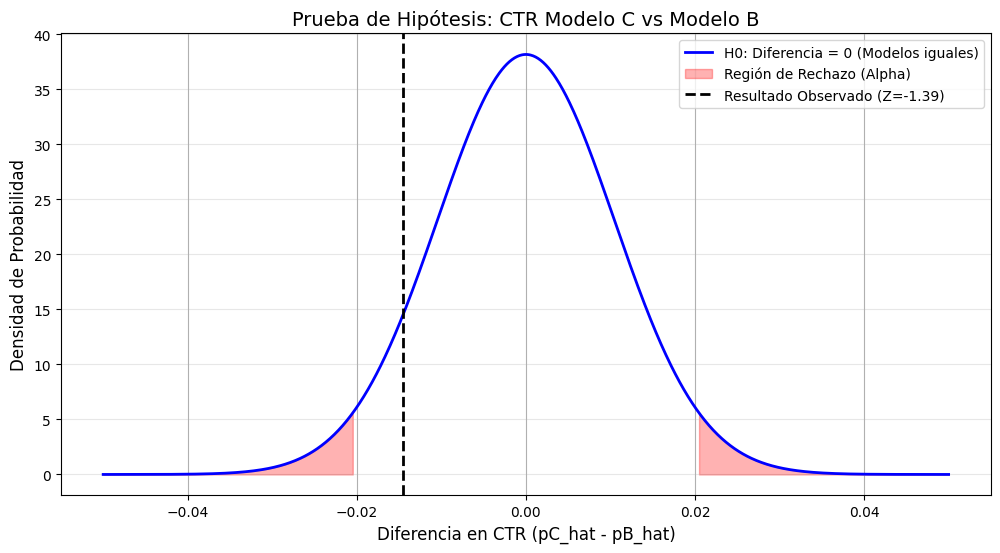

In [77]:
# Con la ayuda de NotBookLM se logra esta visualización

diff_obs = pC_hat_4 - pB_hat_4  # -0.0145

# SE
se = abs(diff_obs / z_stat_4)

# Eje X: Diferencia entre proporciones
x = np.linspace(-0.05, 0.05, 1000)
y_h0 = norm.pdf(x, 0, se) # Distribución bajo H0 (media = 0)

# Valores críticos para Alpha 0.05 (Dos colas)
z_crit = norm.ppf(1 - alpha_4/2)
crit_low = -z_crit * se
crit_high = z_crit * se

plt.figure(figsize=(12, 6))

# Dibujar la distribución nula
plt.plot(x, y_h0, label='H0: Diferencia = 0 (Modelos iguales)', color='blue', lw=2)

# Sombreado de las regiones de rechazo (Alpha)
x_rej_low = np.linspace(-0.05, crit_low, 100)
x_rej_high = np.linspace(crit_high, 0.05, 100)
plt.fill_between(x_rej_low, norm.pdf(x_rej_low, 0, se), color='red', alpha=0.3, label='Región de Rechazo (Alpha)')
plt.fill_between(x_rej_high, norm.pdf(x_rej_high, 0, se), color='red', alpha=0.3)

# Dibujar el valor observado (Tu Z-statistic)
plt.axvline(diff_obs, color='black', linestyle='--', lw=2, label=f'Resultado Observado (Z={z_stat:.2f})')

# Personalización
plt.title('Prueba de Hipótesis: CTR Modelo C vs Modelo B', fontsize=14)
plt.xlabel('Diferencia en CTR (pC_hat - pB_hat)', fontsize=12)
plt.ylabel('Densidad de Probabilidad', fontsize=12)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

Con base en los resultados y la visualización lograda con la ayuda de NotebookLM,no existe diferencia suficiente soportada estadísticamente para rechazar la hipótesis nula que indica que los modelos son iguales, por lo tanto, prevalece.
El resultado observado se encuentra fuera de la zona de rechazo, marcada en el gráfico anterior en rojo.

### 5. **Tamaño de muestra:**
Si quieres un margen de error de 1 punto porcentual ($e=0.01$) y esperas $p=0.12$, ¿cuántas impresiones necesitas por modelo? **= 4057**

---
Con el uso de la fórmula de Cochran :(Nanjundeswaraswamy & Divakara, 2021)
$$n_0=\frac{Z^2*p*q}{e^2}$$


In [81]:
z_5 = 1.96  # for a 95% confidence interval
p_5 = 0.12  # expected CTR
e_5 = 0.01  # margin of error

n_required_per_model = (z_5**2 * p_5 * (1-p_5)) / (e_5**2)

print_bold("Tamaño de muestra necesario por modelo:")
print(f"- Para un CTR esperado de {p_5*100:.0f}% y un margen de error de \u00b1{e_5*100:.0f}% (con 95% de confianza):")
print(f"  Se necesitan aproximadamente {n_required_per_model:.0f} impresiones por modelo.")


Tamaño de muestra necesario por modelo:
- Para un CTR esperado de 12% y un margen de error de ±1% (con 95% de confianza):
  Se necesitan aproximadamente 4057 impresiones por modelo.


# Referencias
Nanjundeswaraswamy, D., & Divakara, S. (2021). DETERMINATION OF SAMPLE SIZE AND SAMPLING METHODS IN APPLIED RESEARCH. Proceedings on Engineering Sciences, 3, 25–32. https://doi.org/10.24874/PES03.01.003
